In [2]:
import os, sys
from pathlib import Path

# Force explicitement la racine du projet
project_root = r"C:\Users\pc\Documents\credit-risk-scoring"
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f"WD: {os.getcwd()}")

WD: C:\Users\pc\Documents\credit-risk-scoring


In [4]:
import os, sys
from pathlib import Path

os.chdir(Path.cwd().parent) if 'credit-risk-scoring' not in os.getcwd() else None
sys.path.insert(0, os.getcwd())

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')

# Chargement dataset final
with open('data/processed/dataset_final.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train_scaled']
X_test  = data['X_test_scaled']
y_train = data['y_train']
y_test  = data['y_test']
feature_names = data['feature_names']

print(f" Dataset chargé")
print(f"   Train : {X_train.shape}")
print(f"   Test  : {X_test.shape}")

 Dataset chargé
   Train : (24000, 16)
   Test  : (6000, 16)


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Baseline
baseline = DummyClassifier(strategy="stratified", random_state=42)
baseline.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f"Baseline ROC-AUC : {baseline_auc:.4f}")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest ROC-AUC : {rf_auc:.4f}")
print(f"\n{classification_report(y_test, rf.predict(X_test))}")

Baseline ROC-AUC : 0.4951
Random Forest ROC-AUC : 0.7752

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.51      0.55      0.53      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.70      0.70      6000
weighted avg       0.79      0.79      0.79      6000



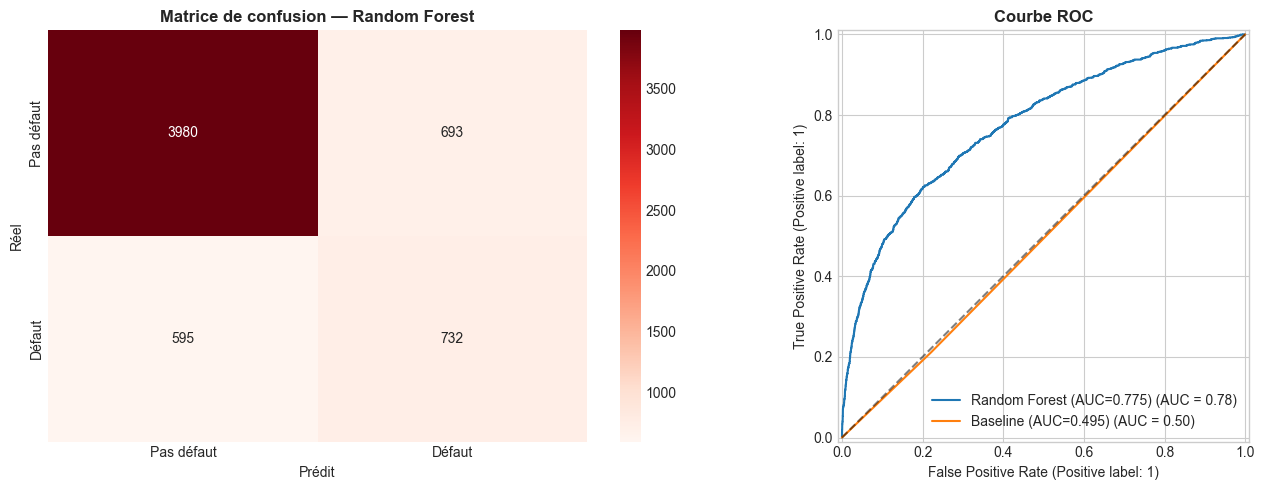

Faux négatifs : 595 clients défaut non détectés
Faux positifs : 693 bons clients refusés


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Pas défaut', 'Défaut'],
            yticklabels=['Pas défaut', 'Défaut'])
axes[0].set_title('Matrice de confusion — Random Forest', fontweight='bold')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Courbe ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=axes[1],
                                name=f'Random Forest (AUC={rf_auc:.3f})')
RocCurveDisplay.from_estimator(baseline, X_test, y_test, ax=axes[1],
                                name=f'Baseline (AUC={baseline_auc:.3f})')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)

plt.tight_layout()
plt.savefig('notebooks/roc_confusion.png', dpi=150)
plt.show()
print(f"Faux négatifs : {cm[1][0]} clients défaut non détectés")
print(f"Faux positifs : {cm[0][1]} bons clients refusés")

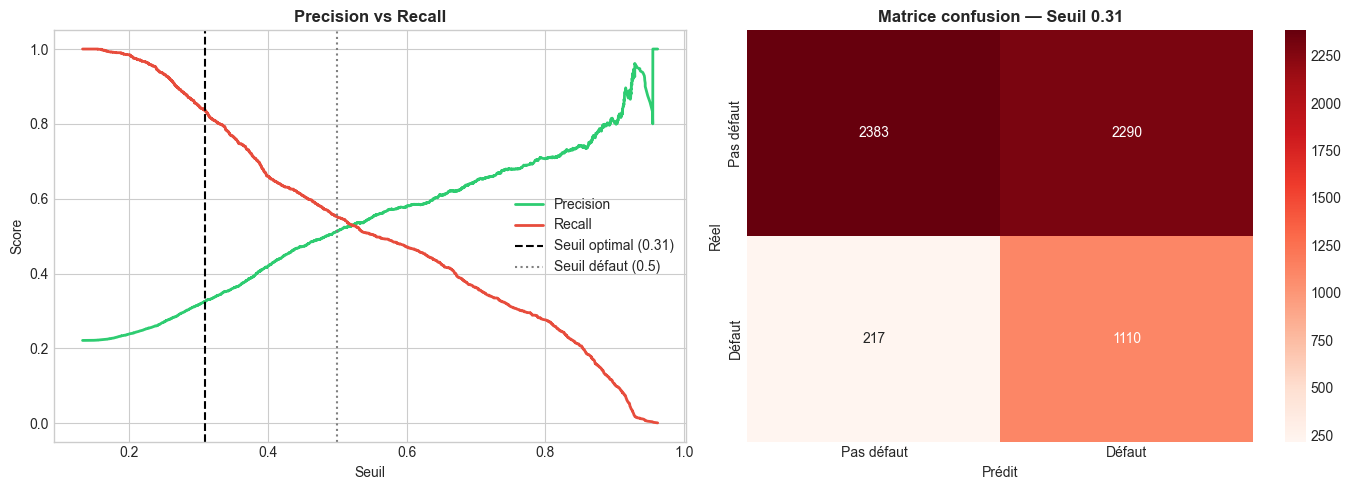

=== Comparaison seuil 0.5 vs 0.31 ===
Seuil 0.50 — Faux négatifs : 595  | Faux positifs : 693
Seuil 0.31 — Faux négatifs : 217 | Faux positifs : 2290

Rappel défaut : 83.65%


In [7]:
from sklearn.metrics import precision_recall_curve
import numpy as np

y_proba = rf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F2 score — pénalise 2x plus les faux négatifs
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-9)
best_idx   = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision vs Recall selon seuil
axes[0].plot(thresholds, precisions[:-1], label='Precision', color='#2ecc71', linewidth=2)
axes[0].plot(thresholds, recalls[:-1], label='Recall', color='#e74c3c', linewidth=2)
axes[0].axvline(x=best_threshold, color='black', linestyle='--',
                label=f'Seuil optimal ({best_threshold:.2f})')
axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision vs Recall', fontweight='bold')
axes[0].legend()

# Comparaison avant/après
y_pred_optimal = (y_proba >= best_threshold).astype(int)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Pas défaut', 'Défaut'],
            yticklabels=['Pas défaut', 'Défaut'])
axes[1].set_title(f'Matrice confusion — Seuil {best_threshold:.2f}', fontweight='bold')
axes[1].set_ylabel('Réel')
axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('notebooks/threshold_optimization.png', dpi=150)
plt.show()

print(f"=== Comparaison seuil 0.5 vs {best_threshold:.2f} ===")
print(f"Seuil 0.50 — Faux négatifs : 595  | Faux positifs : 693")
print(f"Seuil {best_threshold:.2f} — Faux négatifs : {cm_optimal[1][0]} | Faux positifs : {cm_optimal[0][1]}")
print(f"\nRappel défaut : {cm_optimal[1][1]/(cm_optimal[1][0]+cm_optimal[1][1]):.2%}")

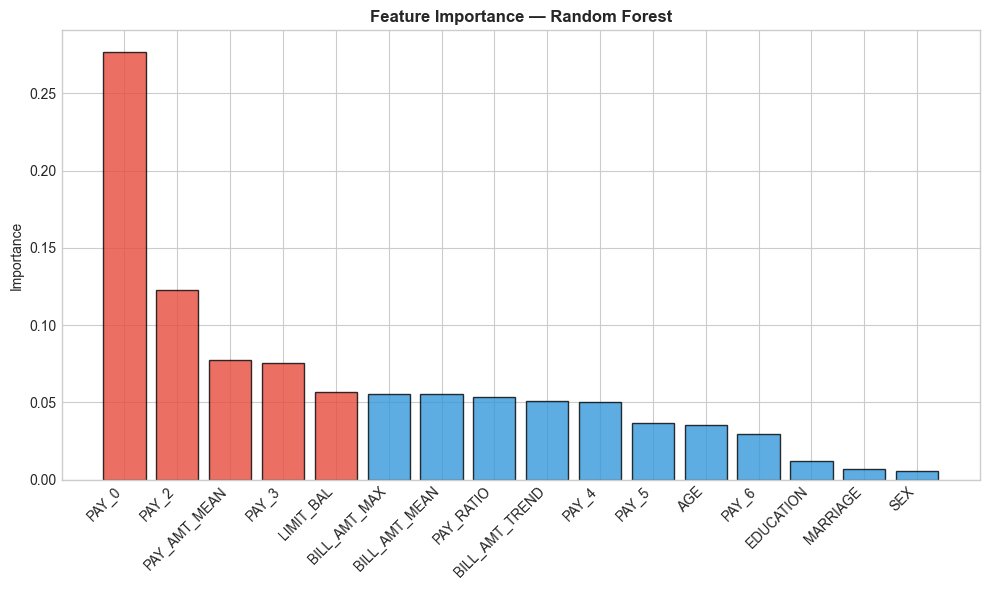

=== Top 5 features les plus importantes ===
  1. PAY_0 : 0.2768
  2. PAY_2 : 0.1226
  3. PAY_AMT_MEAN : 0.0777
  4. PAY_3 : 0.0756
  5. LIMIT_BAL : 0.0568


In [8]:
# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(importances))]
ax.bar(range(len(importances)),
       importances[indices],
       color=[colors[i] for i in range(len(importances))],
       edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_title('Feature Importance — Random Forest', fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('notebooks/feature_importance.png', dpi=150)
plt.show()

print("=== Top 5 features les plus importantes ===")
for i in range(5):
    print(f"  {i+1}. {feature_names[indices[i]]} : {importances[indices[i]]:.4f}")